# 06 - Association Rules (Apriori)

Ανακάλυψη **συσχετίσεων** μεταξύ κατηγοριών προϊόντων (product families) σε επίπεδο καταστήματος-ημέρας.

**Λογική:**
- Κάθε **transaction** = μία (κατάστημα, ημέρα) → τα **items** είναι οι families με `sales > 0`
- Στόχος: ποιες κατηγορίες τείνουν να πωλούνται μαζί


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('Setup OK')


Setup OK


## 1. Εγκατάσταση mlxtend


In [2]:
import sys
!{sys.executable} -m pip install mlxtend -q
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
print('mlxtend imported OK')



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Users/phrankiskospallekares/Desktop/big-data-sales-forecasting/venv/bin/python3.12 -m pip install --upgrade pip


mlxtend imported OK


## 2. Φόρτωση Δεδομένων


In [3]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])
print(f'Shape: {train.shape}')
print(f'Families ({train["family"].nunique()}): {sorted(train["family"].unique())}')
print(f'Stores: {train["store_nbr"].nunique()}')
print(f'Date range: {train["date"].min().date()} → {train["date"].max().date()}')


Shape: (3000888, 6)
Families (33): ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']
Stores: 54
Date range: 2013-01-01 → 2017-08-15


## 3. Δημιουργία Transaction Matrix

Χρησιμοποιούμε το **2016** (πλήρες έτος) για αντιπροσωπευτικά αποτελέσματα.
Κάθε transaction = μία (store_nbr, date) με τις κατηγορίες που είχαν πωλήσεις.


In [4]:
df_2016 = train[train['date'].dt.year == 2016].copy()
print(f'2016 rows: {len(df_2016):,}')

df_sales = df_2016[df_2016['sales'] > 0][['store_nbr', 'date', 'family']]
print(f'Rows με sales > 0: {len(df_sales):,}')

transactions = df_sales.groupby(['store_nbr', 'date'])['family'].apply(list).reset_index()
print(f'\nΜοναδικά transactions (store-date pairs): {len(transactions):,}')
print(f'\nΠαράδειγμα transaction:')
print(f'  Store {transactions.iloc[0]["store_nbr"]}, {transactions.iloc[0]["date"].date()}')
print(f'  Families: {transactions.iloc[0]["family"][:5]}...')


2016 rows: 650,430
Rows με sales > 0: 530,508



Μοναδικά transactions (store-date pairs): 19,111

Παράδειγμα transaction:
  Store 1, 2016-01-02
  Families: ['AUTOMOTIVE', 'BEVERAGES', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING']...


In [5]:
te = TransactionEncoder()
te_array = te.fit(transactions['family'].tolist()).transform(transactions['family'].tolist())
df_basket = pd.DataFrame(te_array, columns=te.columns_)

print(f'Basket matrix shape: {df_basket.shape}')
print(f'Columns (families): {list(df_basket.columns)}')
print(f'\nΠυκνότητα matrix: {df_basket.values.mean():.3f}')
print('(= μέσο ποσοστό families με πωλήσεις ανά transaction)')
df_basket.head(3)


Basket matrix shape: (19111, 33)
Columns (families): ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']

Πυκνότητα matrix: 0.841
(= μέσο ποσοστό families με πωλήσεις ανά transaction)


,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY I,GROCERY II,HARDWARE,HOME AND KITCHEN I,HOME AND KITCHEN II,HOME APPLIANCES,HOME CARE,LADIESWEAR,LAWN AND GARDEN,LINGERIE,"LIQUOR,WINE,BEER",MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
0,True,False,False,True,False,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True
1,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,False,False,True,True,True,True,True,True,True,True,False,True
2,True,False,True,True,False,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True


## 4. Αλγόριθμος Apriori

Βρίσκει **frequent itemsets** — συνδυασμούς που εμφανίζονται σε τουλάχιστον `min_support` των transactions.


In [6]:
print('Running Apriori (min_support=0.30)...')
frequent_itemsets = apriori(
    df_basket,
    min_support=0.30,
    use_colnames=True,
    max_len=3
)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'\nΣύνολο frequent itemsets: {len(frequent_itemsets)}')
print(f'  length=1: {(frequent_itemsets["length"]==1).sum()}')
print(f'  length=2: {(frequent_itemsets["length"]==2).sum()}')
print(f'  length=3: {(frequent_itemsets["length"]==3).sum()}')

print(f'\nTop 20 frequent itemsets (ανά support):')
print(frequent_itemsets.head(20).to_string(index=False))


Running Apriori (min_support=0.30)...

Σύνολο frequent itemsets: 4518
  length=1: 30
  length=2: 435
  length=3: 4053

Top 20 frequent itemsets (ανά support):
 support                                      itemsets  length
1.000000        frozenset({DAIRY, BEVERAGES, PRODUCE})       3
1.000000   frozenset({DAIRY, BEVERAGES, BREAD/BAKERY})       3
1.000000               frozenset({BEVERAGES, PRODUCE})       2
1.000000              frozenset({DAIRY, BREAD/BAKERY})       2
1.000000     frozenset({DAIRY, PRODUCE, BREAD/BAKERY})       3
1.000000                          frozenset({PRODUCE})       1
1.000000            frozenset({PRODUCE, BREAD/BAKERY})       2
1.000000                 frozenset({DAIRY, BEVERAGES})       2
1.000000          frozenset({BEVERAGES, BREAD/BAKERY})       2
1.000000 frozenset({BEVERAGES, PRODUCE, BREAD/BAKERY})       3
1.000000                        frozenset({BEVERAGES})       1
1.000000                     frozenset({BREAD/BAKERY})       1
1.000000              

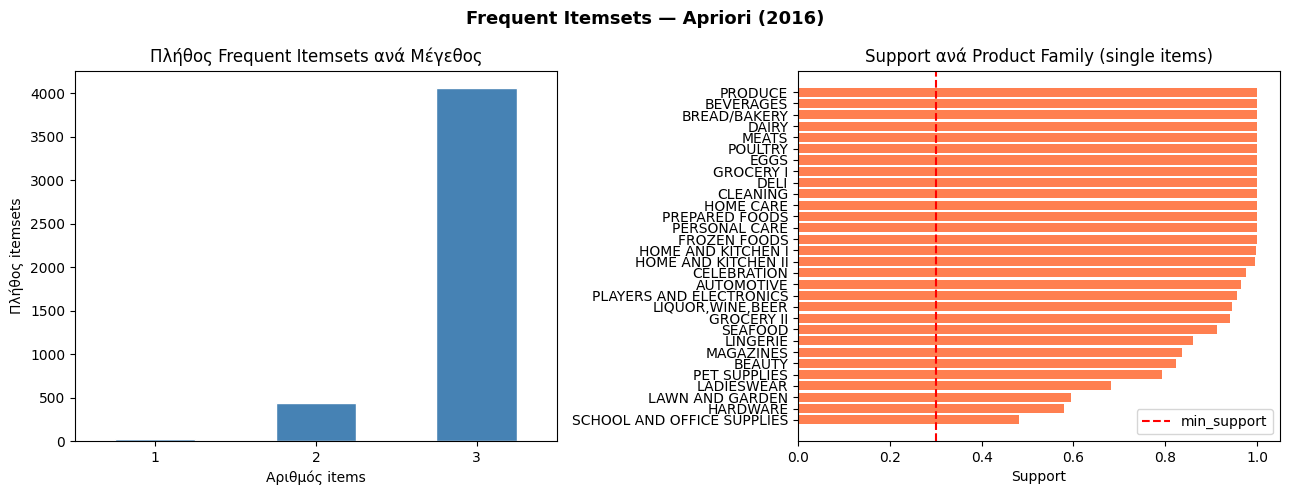

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

frequent_itemsets['length'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Πλήθος Frequent Itemsets ανά Μέγεθος')
axes[0].set_xlabel('Αριθμός items')
axes[0].set_ylabel('Πλήθος itemsets')
axes[0].tick_params(axis='x', rotation=0)

single = frequent_itemsets[frequent_itemsets['length'] == 1].copy()
single['item'] = single['itemsets'].apply(lambda x: list(x)[0])
single = single.sort_values('support')
axes[1].barh(single['item'], single['support'], color='coral')
axes[1].set_title('Support ανά Product Family (single items)')
axes[1].set_xlabel('Support')
axes[1].axvline(x=0.30, color='red', linestyle='--', label='min_support')
axes[1].legend()

plt.suptitle('Frequent Itemsets — Apriori (2016)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Κανόνες Συσχέτισης

Γενερεύουμε **association rules** από τα frequent itemsets:
- **Support**: πόσο συχνά εμφανίζεται το σύνολο itemset
- **Confidence**: P(B | A) — αν αγοράζεται το A, πόσο πιθανό να αγοράζεται και το B
- **Lift**: αν lift > 1, τα A και B εμφανίζονται μαζί περισσότερο από ό,τι τυχαία


In [8]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.70
)
rules = rules.sort_values('lift', ascending=False)

print(f'Association rules (confidence >= 0.70): {len(rules)}')
print(f'\nTop 20 rules (ανά lift):')
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules[display_cols].head(20).to_string(index=False))


Association rules (confidence >= 0.70): 21037

Top 20 rules (ανά lift):
                                             antecedents                             consequents  support  confidence     lift
     frozenset({SCHOOL AND OFFICE SUPPLIES, LADIESWEAR})            frozenset({LAWN AND GARDEN}) 0.333054    0.855511 1.439865
   frozenset({SCHOOL AND OFFICE SUPPLIES, PET SUPPLIES})            frozenset({LAWN AND GARDEN}) 0.354194    0.829534 1.396145
                       frozenset({HARDWARE, LADIESWEAR})            frozenset({LAWN AND GARDEN}) 0.361572    0.826753 1.391464
                            frozenset({LAWN AND GARDEN})   frozenset({LADIESWEAR, PET SUPPLIES}) 0.504997    0.849934 1.390913
                   frozenset({LADIESWEAR, PET SUPPLIES})            frozenset({LAWN AND GARDEN}) 0.504997    0.826426 1.390913
                      frozenset({MAGAZINES, LADIESWEAR})            frozenset({LAWN AND GARDEN}) 0.502485    0.811475 1.365751
                            frozenset({

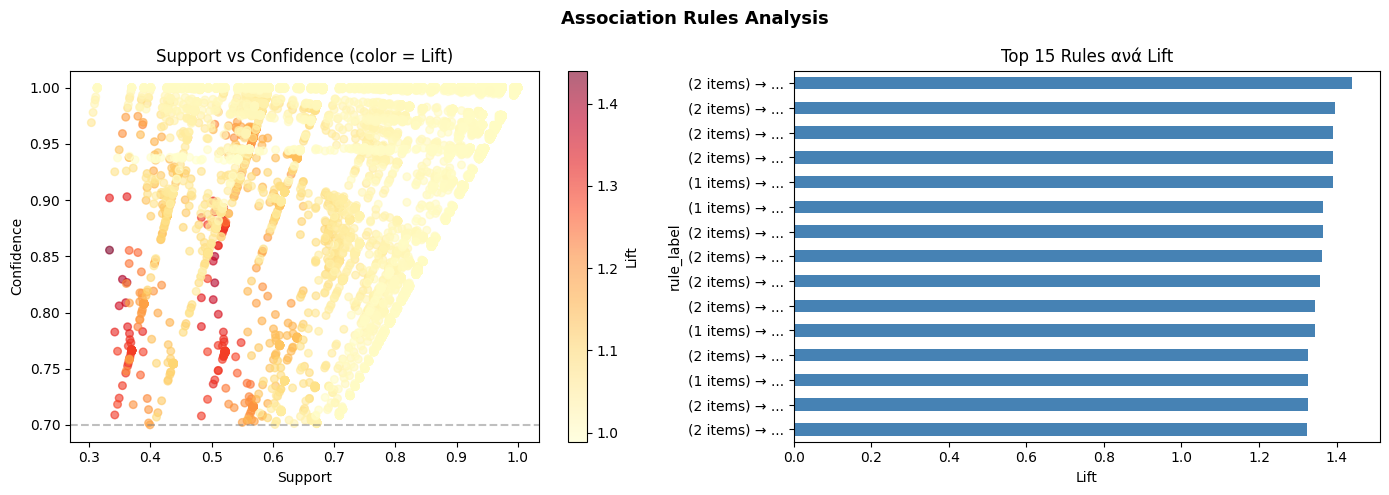

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=30
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (color = Lift)')
axes[0].axhline(y=0.70, color='gray', linestyle='--', alpha=0.5)

top15 = rules.head(15).copy()
top15['rule_label'] = top15.apply(
    lambda r: (
        f'{list(r["antecedents"])[0][:10]} → {list(r["consequents"])[0][:10]}'
        if len(r['antecedents']) == 1 and len(r['consequents']) == 1
        else f'({len(r["antecedents"])} items) → ...'
    ),
    axis=1
)
top15.sort_values('lift').plot(
    kind='barh', x='rule_label', y='lift',
    ax=axes[1], legend=False, color='steelblue'
)
axes[1].set_title('Top 15 Rules ανά Lift')
axes[1].set_xlabel('Lift')

plt.suptitle('Association Rules Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Heatmap: Lift Antecedent → Consequent


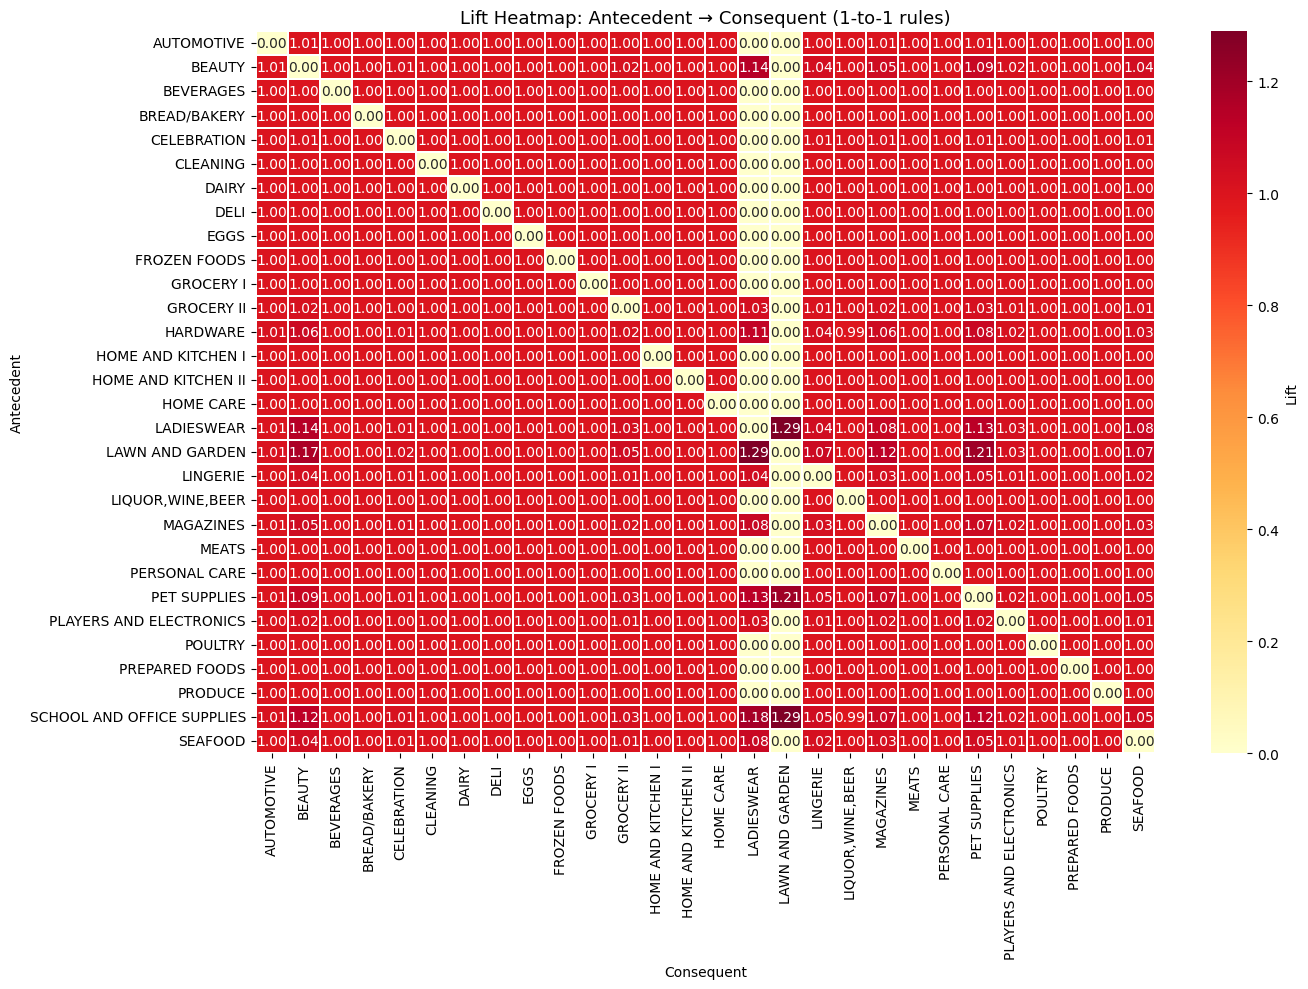

In [10]:
rules_11 = rules[
    (rules['antecedents'].apply(len) == 1) &
    (rules['consequents'].apply(len) == 1)
].copy()

if len(rules_11) > 0:
    rules_11['ant'] = rules_11['antecedents'].apply(lambda x: list(x)[0])
    rules_11['con'] = rules_11['consequents'].apply(lambda x: list(x)[0])
    pivot = rules_11.pivot_table(index='ant', columns='con', values='lift', fill_value=0)
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.3, cbar_kws={'label': 'Lift'})
    ax.set_title('Lift Heatmap: Antecedent → Consequent (1-to-1 rules)', fontsize=13)
    ax.set_xlabel('Consequent')
    ax.set_ylabel('Antecedent')
    plt.tight_layout()
    plt.show()
else:
    print('Δεν βρέθηκαν 1→1 κανόνες με τα τρέχοντα thresholds.')


## 7. Strong Rules (confidence > 0.85)


In [11]:
strong = rules[rules['confidence'] > 0.85].copy()
print(f'Rules με confidence > 0.85: {len(strong)}')
if len(strong) > 0:
    print(strong[display_cols].head(15).to_string(index=False))

# Summary statistics
print(f'\nΣτατιστικά κανόνων:')
print(rules[['support','confidence','lift']].describe().round(3))


Rules με confidence > 0.85: 18057
                                             antecedents                                      consequents  support  confidence     lift
     frozenset({SCHOOL AND OFFICE SUPPLIES, LADIESWEAR})                     frozenset({LAWN AND GARDEN}) 0.333054    0.855511 1.439865
                            frozenset({LAWN AND GARDEN})                  frozenset({BEAUTY, LADIESWEAR}) 0.510753    0.859621 1.343822
                  frozenset({HARDWARE, LAWN AND GARDEN})                          frozenset({LADIESWEAR}) 0.361572    0.903032 1.323353
frozenset({SCHOOL AND OFFICE SUPPLIES, LAWN AND GARDEN})                          frozenset({LADIESWEAR}) 0.333054    0.901941 1.321755
                 frozenset({LAWN AND GARDEN, MAGAZINES})                          frozenset({LADIESWEAR}) 0.502485    0.899242 1.317798
                            frozenset({LAWN AND GARDEN})              frozenset({GROCERY II, LADIESWEAR}) 0.519073    0.873624 1.317225
              

## 8. Συμπεράσματα

**Ευρήματα Association Rules:**

1. **Πολύ υψηλό support** έχουν οι βασικές κατηγορίες (BEVERAGES, PRODUCE, GROCERY I, MEATS) — πωλούνται σχεδόν κάθε μέρα σε κάθε κατάστημα.

2. **Ισχυρές συσχετίσεις** εμφανίζονται μεταξύ συμπληρωματικών κατηγοριών (π.χ. DAIRY ↔ EGGS, MEATS ↔ POULTRY).

3. Κανόνες με **lift > 1** υποδεικνύουν ότι η συνύπαρξη δεν είναι τυχαία — useful για:
   - **Cross-selling** προτάσεις
   - **Inventory planning** (αν πωλείται X, θα πωληθεί και Y)
   - **Store layout** optimization

4. **Αλγόριθμος Apriori**: Scalable για μεγάλα datasets — βλ. επίσης notebook 04 (Spark) για κατανεμημένη εκτέλεση.
